In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("../data/final_shop_6modata.csv")
df.head()

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,Sale Amount,P&L
0,Shop - 1:1 - Desk - [shop coupon code],July,16038,6504,0.41,1166,0.10,6669,1.03,6402,136770.05,-267.086
1,Shop - 1:1 - Desk - [shop coupon],July,36462,14367,0.39,2188,0.09,13746,0.96,13262,283215.21,-483.951
2,Shop - 1:1 - Desk - [shop discount code],July,3635,1458,0.40,248,0.09,1606,1.10,1723,39165.46,117.136
3,Shop - 1:1 - Desk - [shop promo code],July,26185,10418,0.40,2294,0.12,13278,1.27,13042,284823.48,-235.921
4,Shop - 1:1 - Desk - [shop promo],July,808,282,0.35,61,0.15,391,1.39,337,7717.77,-53.604


In [3]:
df["Ad Group"].unique()

array(['Shop - 1:1 - Desk - [shop coupon code]',
       'Shop - 1:1 - Desk - [shop coupon]',
       'Shop - 1:1 - Desk - [shop discount code]',
       'Shop - 1:1 - Desk - [shop promo code]',
       'Shop - 1:1 - Desk - [shop promo]',
       'Shop - 1:1 - Mob - [shop coupon code]',
       'Shop - 1:1 - Mob - [shop coupon]',
       'Shop - 1:1 - Mob - [shop discount code]',
       'Shop - 1:1 - Mob - [shop promo code]',
       'Shop - 1:1 - Mob - [shop promo]',
       'Shop - Exact - Desk - Competitor',
       'Shop - Exact - Desk - Coupon Code',
       'Shop - Exact - Desk - Discount Code',
       'Shop - Exact - Desk - Free Shipping',
       'Shop - Exact - Desk - Offer', 'Shop - Exact - Desk - Promo Code',
       'Shop - Exact - Desk - Sale', 'Shop - Exact - Mob - Competitor',
       'Shop - Exact - Mob - Coupon Code',
       'Shop - Exact - Mob - Discount Code',
       'Shop - Exact - Mob - Free Shipping', 'Shop - Exact - Mob - Offer',
       'Shop - Exact - Mob - Promo Code', 'Shop

# Explanation of Ad Group structure:
# "Shop - 1:1 - Desk - [shop coupon code]"
#
# Shop → the brand / campaign source
# 1:1 / Exact / Phrase → Google Ads keyword match strategy
# Desk / Mob → device type (Desktop or Mobile)
# [shop coupon code] → promotion or keyword type
#
# Since all this information is stored in one column,
# we split it into multiple analytical columns later.

shop: the secret identity mall
exact/phrase / 1:1 : Google Ads search strategy
Desk=desktop item
mob= mobile item
*note: separate into columns  

In [4]:
df.isnull().sum()

Ad Group       0
Month          0
Impressions    0
Clicks         0
CTR            0
Conversions    0
Conv Rate      0
Cost           0
CPC            0
Revenue        0
Sale Amount    0
P&L            0
dtype: int64

In [5]:
# Result interpretation:
# All columns show 0 missing values
# This means the dataset is clean and ready for analysis

In [6]:
#ad group splitting

In [7]:
df[['Campaign','Match_Type','Device','Promotion_Type']] = df['Ad Group'].str.split(' - ', expand=True)

df = df[['Match_Type','Device','Promotion_Type'] + 
        [col for col in df.columns if col not in ['Campaign','Match_Type','Device','Promotion_Type']]]

In [8]:
df.head()

,Match_Type,Device,Promotion_Type,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,Sale Amount,P&L
0,1:1,Desk,[shop coupon code],Shop - 1:1 - Desk - [shop coupon code],July,16038,6504,0.41,1166,0.10,6669,1.03,6402,136770.05,-267.086
1,1:1,Desk,[shop coupon],Shop - 1:1 - Desk - [shop coupon],July,36462,14367,0.39,2188,0.09,13746,0.96,13262,283215.21,-483.951
2,1:1,Desk,[shop discount code],Shop - 1:1 - Desk - [shop discount code],July,3635,1458,0.40,248,0.09,1606,1.10,1723,39165.46,117.136
3,1:1,Desk,[shop promo code],Shop - 1:1 - Desk - [shop promo code],July,26185,10418,0.40,2294,0.12,13278,1.27,13042,284823.48,-235.921
4,1:1,Desk,[shop promo],Shop - 1:1 - Desk - [shop promo],July,808,282,0.35,61,0.15,391,1.39,337,7717.77,-53.604


In [9]:
# Result:
# We now have separate analytical columns for:
# Match_Type → campaign keyword targeting strategy
# Device → desktop or mobile
# Promotion_Type → promotion / keyword type

In [10]:
#working on devices
df['Device'].value_counts()

Device
Mob     96
Desk    94
Name: count, dtype: int64

In [11]:
# This confirms the dataset is balanced between desktop and mobile campaigns

In [12]:
device_totals = df.groupby('Device')[['Revenue','Cost','P&L']].sum()

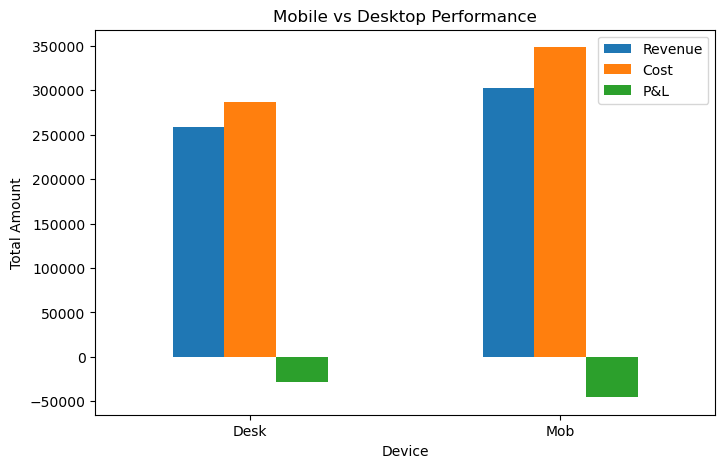

In [13]:
device_totals.plot(kind='bar', figsize=(8,5))

plt.title('Mobile vs Desktop Performance')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.show()

In [14]:
# Insight:
# Both mobile and desktop advertising campaigns generated negative P&L,
#meaning the advertising costs exceeded the revenue generated. 
#However, the losses were greater for mobile campaigns.

In [15]:
sales_device = df.groupby('Device')['Sale Amount'].sum()

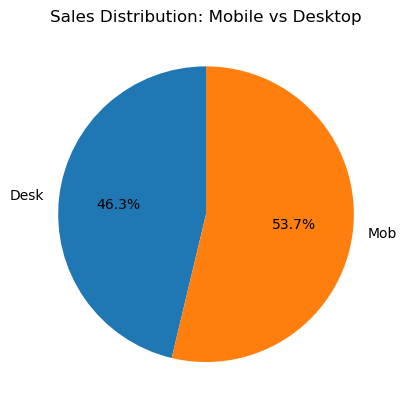

In [16]:
sales_device.plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Sales Distribution: Mobile vs Desktop')
plt.ylabel('')
plt.show()

In [17]:
#Mobile ads generated 53% of total sales, indicating higher sales volume. However, they resulted in larger financial losses, 
#suggesting that mobile campaigns may have higher costs, lower conversion efficiency, 
#or lower revenue per sale compared to desktop campaigns.

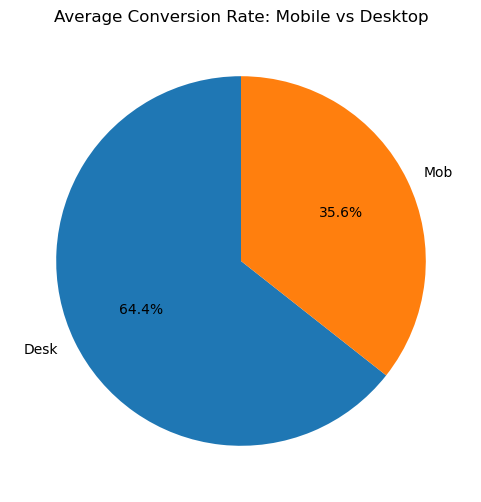

In [18]:
conv_rate_device = df.groupby('Device')['Conv Rate'].mean()
conv_rate_device.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6,6))

plt.title('Average Conversion Rate: Mobile vs Desktop')
plt.ylabel('')  # remove y-axis label for clarity
plt.show()

In [19]:
df.groupby('Device')['Clicks'].sum()


Device
Desk    234939
Mob     689564
Name: Clicks, dtype: int64

In [20]:
#Mobile campaigns generate more clicks than desktop campaigns,
#but the conversion rate is significantly lower. 
#This suggests that mobile users are interested but not converting efficiently.
#Implementing post-click incentives, such as pop-up offers or promo codes, 
#could increase conversions and improve the profitability of mobile campaigns

In [21]:
df.groupby('Device')['Conversions'].mean()

Device
Desk    448.829787
Mob     560.479167
Name: Conversions, dtype: float64

In [22]:
match_metrics = df.groupby('Match_Type')[['Impressions','Clicks','CTR','Conversions','Conv Rate']].mean()

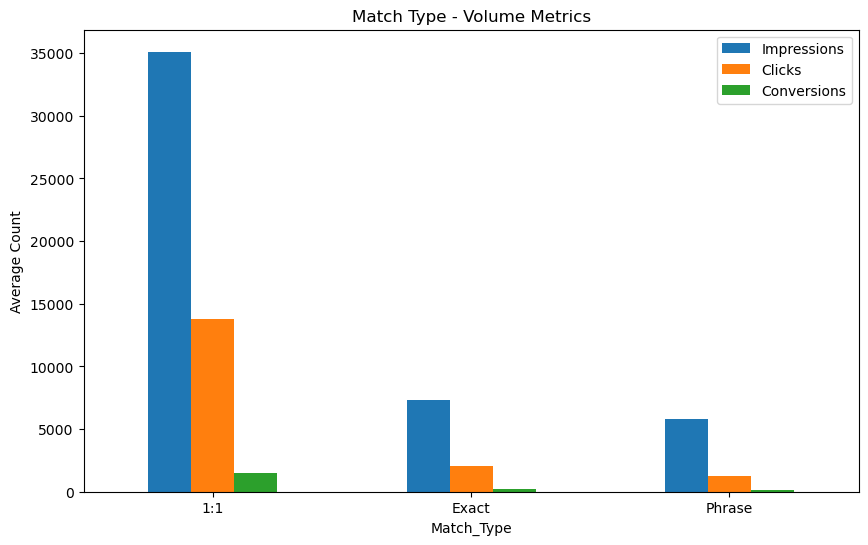

In [23]:
match_metrics[['Impressions','Clicks','Conversions']].plot(kind='bar', figsize=(10,6))

plt.title('Match Type - Volume Metrics')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.show()

In [24]:
#The 1:1 campaign structure (one keyword per ad group) generates the highest number of impressions and clicks. 
#This may occur because the campaign targets many individual keywords, 
#each with tailored ads, allowing it to capture a wider range of search traffic.

In [25]:
match_rates = df.groupby('Match_Type')[['CTR','Conv Rate']].mean().reset_index()

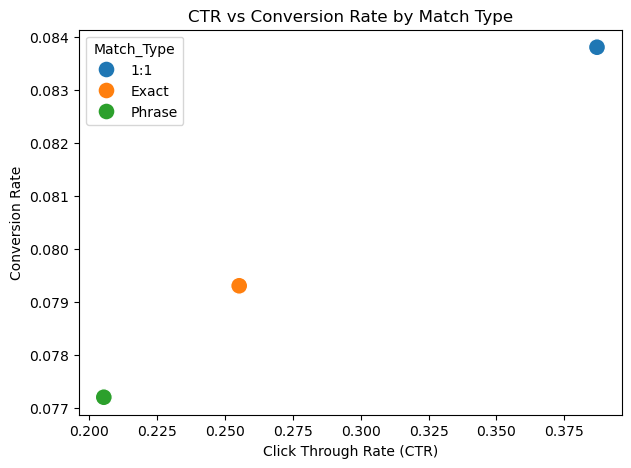

In [26]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=match_rates, x='CTR', y='Conv Rate', hue='Match_Type', s=150)

plt.title('CTR vs Conversion Rate by Match Type')
plt.xlabel('Click Through Rate (CTR)')
plt.ylabel('Conversion Rate')
plt.show()

In [27]:
#Exact and Phrase match campaigns generate fewer impressions and clicks, 
#as they restrict when ads appear based on how closely a user’s search matches the targeted keyword.

In [28]:
match_promo = pd.crosstab(df['Promotion_Type'], df['Match_Type'])

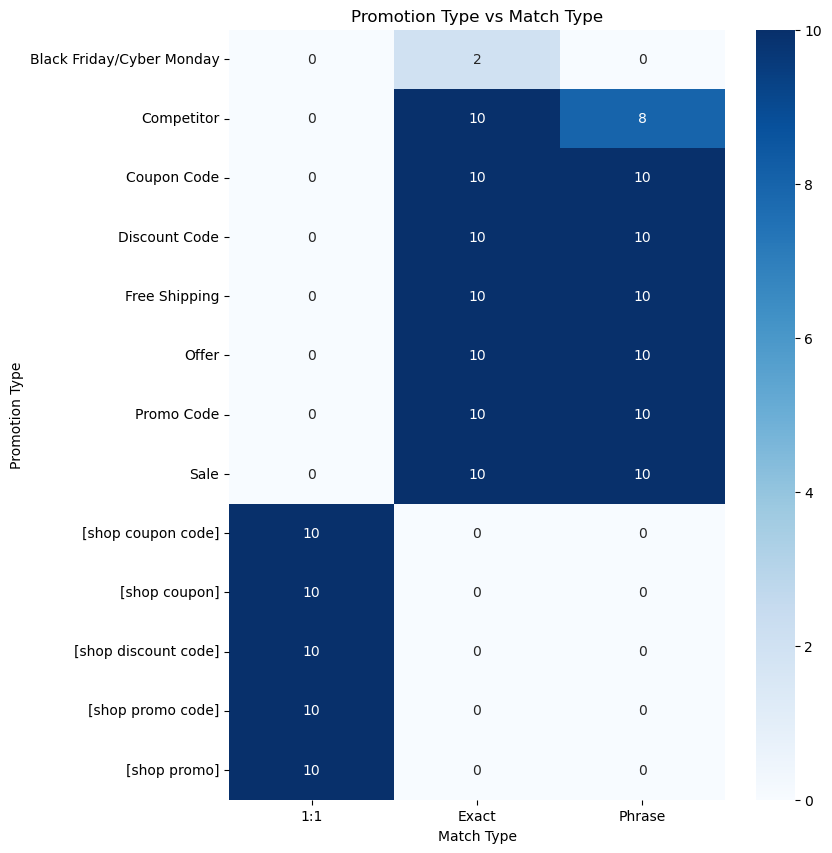

In [29]:
plt.figure(figsize=(8,10))

sns.heatmap(match_promo, annot=True, fmt='d', cmap='Blues')

plt.title('Promotion Type vs Match Type')
plt.xlabel('Match Type')
plt.ylabel('Promotion Type')
plt.show()

In [30]:
promo_performance = df.groupby(['Match_Type','Promotion_Type'])[['CTR','Conv Rate','P&L','CPC']].mean().reset_index()
promo_performance

,Match_Type,Promotion_Type,CTR,Conv Rate,P&L,CPC
0,1:1,[shop coupon code],0.41400,0.081,-1037.188900,0.89300
1,1:1,[shop coupon],0.37200,0.064,-2390.287600,0.68100
2,1:1,[shop discount code],0.39600,0.076,-148.162000,0.94800
3,1:1,[shop promo code],0.41400,0.100,-1257.975700,1.08100
4,1:1,[shop promo],0.33900,0.098,-41.310200,1.04300
5,Exact,Black Friday/Cyber Monday,0.08000,0.185,78.954500,0.15500
6,Exact,Competitor,0.27600,0.069,-53.215900,0.75700
7,Exact,Coupon Code,0.33100,0.067,-353.262600,0.75900
8,Exact,Discount Code,0.24900,0.062,-210.187700,0.78100
9,Exact,Free Shipping,0.26000,0.110,-17.795100,0.31600


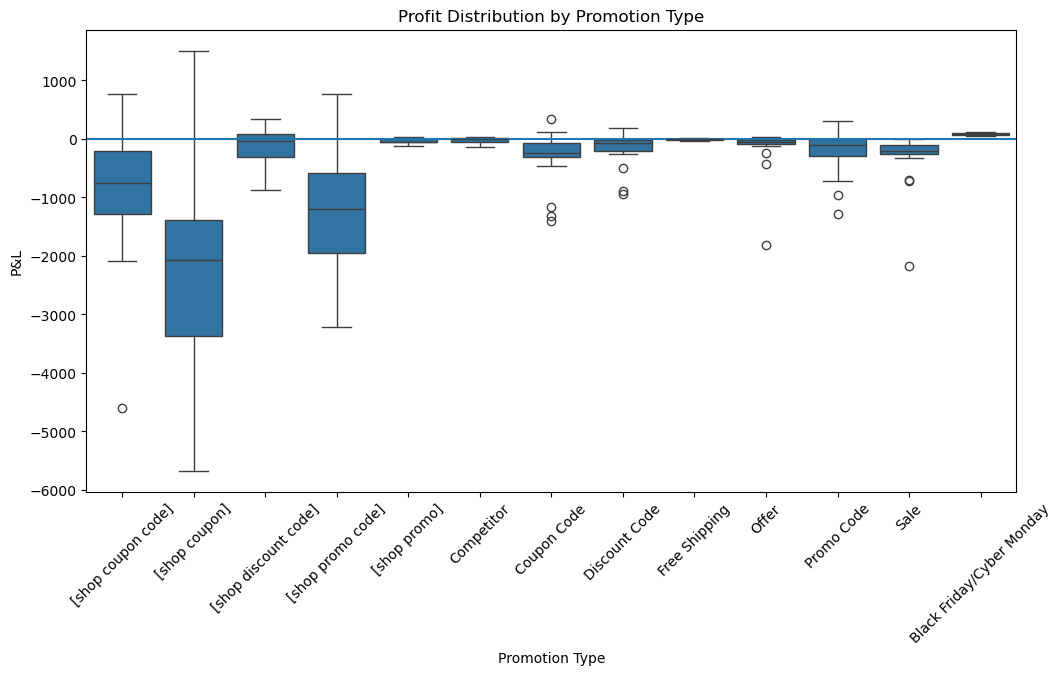

In [31]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Promotion_Type',
    y='P&L'
)

plt.title('Profit Distribution by Promotion Type')
plt.xlabel('Promotion Type')
plt.ylabel('P&L')
plt.xticks(rotation=45)
plt.axhline(0)

plt.show()

In [32]:
#Promotion types containing “code” (e.g., shop coupon code, shop discount code, shop promo code) have the highest CTR. 
#This indicates that users are highly attracted to promotions offering codes, 
#regardless of the specific type, likely because they perceive these offers as opportunities to save money.


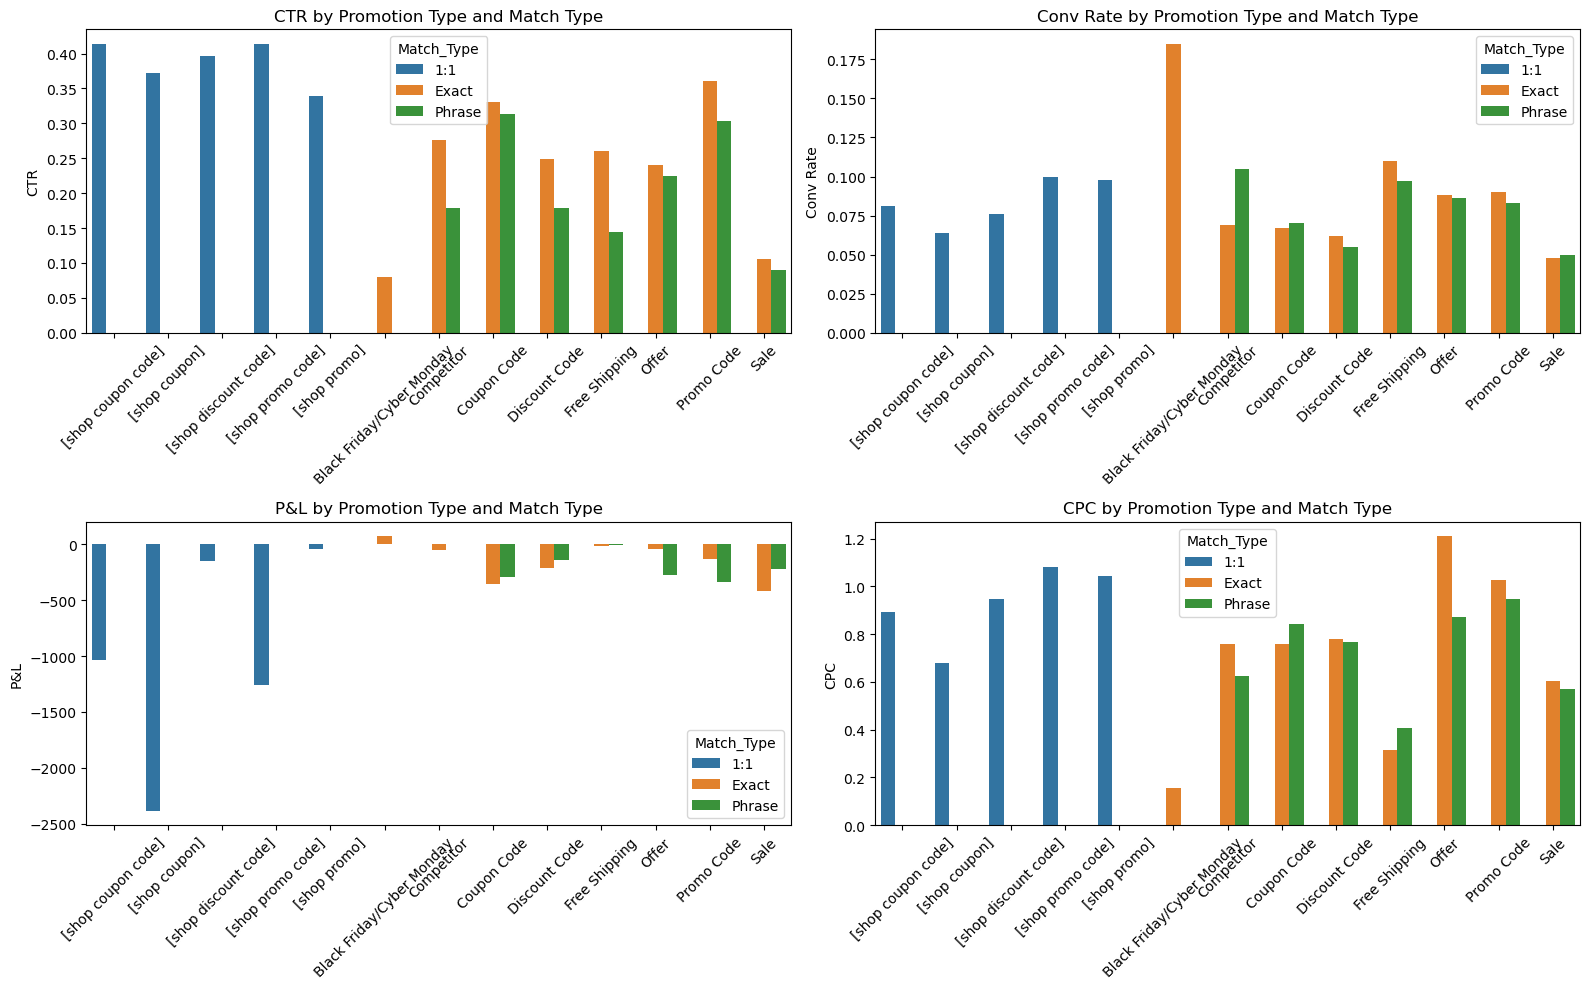

In [33]:
metrics = ['CTR', 'Conv Rate', 'P&L', 'CPC']

fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=promo_performance, 
        x='Promotion_Type', 
        y=metric, 
        hue='Match_Type', 
        ax=axes[i]
    )
    axes[i].set_title(metric + ' by Promotion Type and Match Type')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
#Most promotion types have similar average conversion rates, except for promotions tied to special events like Black Friday/Cyber Monday,
#which have higher conversion rates. This makes sense because users who click on these time-limited offers are motivated to purchase
#before the deal ends.

#Change over time

In [35]:
df['Month'] = df['Month'].str.strip().str.capitalize()

In [36]:
month_order = ['July','August','September','October','November']

In [37]:
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

In [38]:
month_performance = df.groupby('Month', observed=True)[['Revenue','Cost','Conversions','P&L','CTR','Conv Rate','CPC','Sale Amount']].sum()
month_performance  

,Revenue,Cost,Conversions,P&L,CTR,Conv Rate,CPC,Sale Amount
Month,,,,,,,,
July,98615,120541,17762,-21922.857,10.64,3.06,29.85,2148710.32
August,72116,84225,12230,-12106.978,10.40,2.68,31.12,1605066.00
September,59093,71597,9425,-12503.474,10.84,2.82,29.85,1319949.14
October,79303,78256,13312,1046.212,10.42,3.22,29.57,1676593.50
November,252833,280753,43267,-27921.667,9.40,3.37,29.95,5298755.35


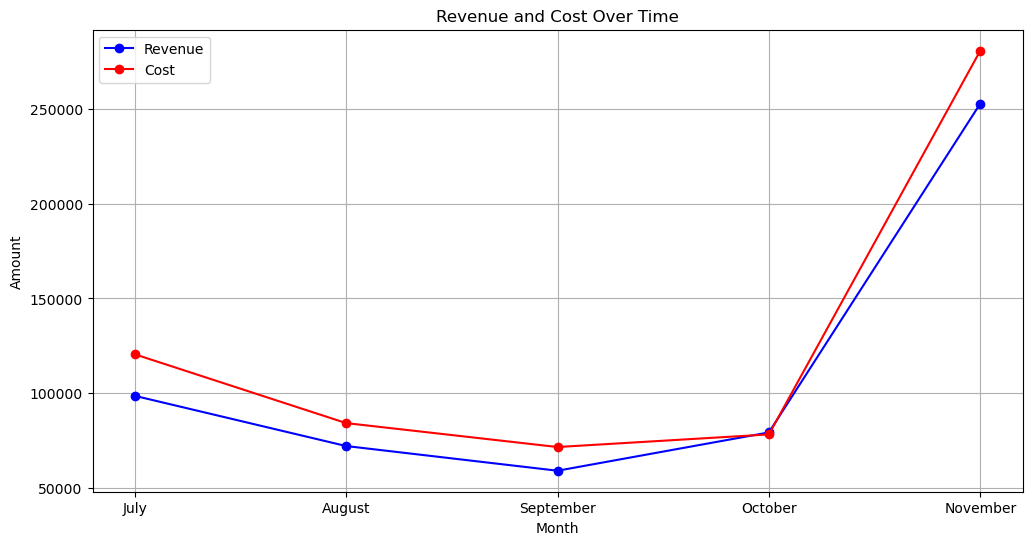

In [39]:
plt.figure(figsize=(12,6))

# Revenue line
plt.plot(month_performance.index, month_performance['Revenue'], marker='o', color='blue', label='Revenue')

# Cost line
plt.plot(month_performance.index, month_performance['Cost'], marker='o', color='red', label='Cost')

plt.title('Revenue and Cost Over Time')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend()
plt.show()

In [40]:
#•	November: Despite having the best conversion rate, P&L was highly negative. This is likely because impressions were extremely high but
#clicks were relatively low, meaning many users saw the ads but did not interact. This shows high visibility but lower engagement efficiency.

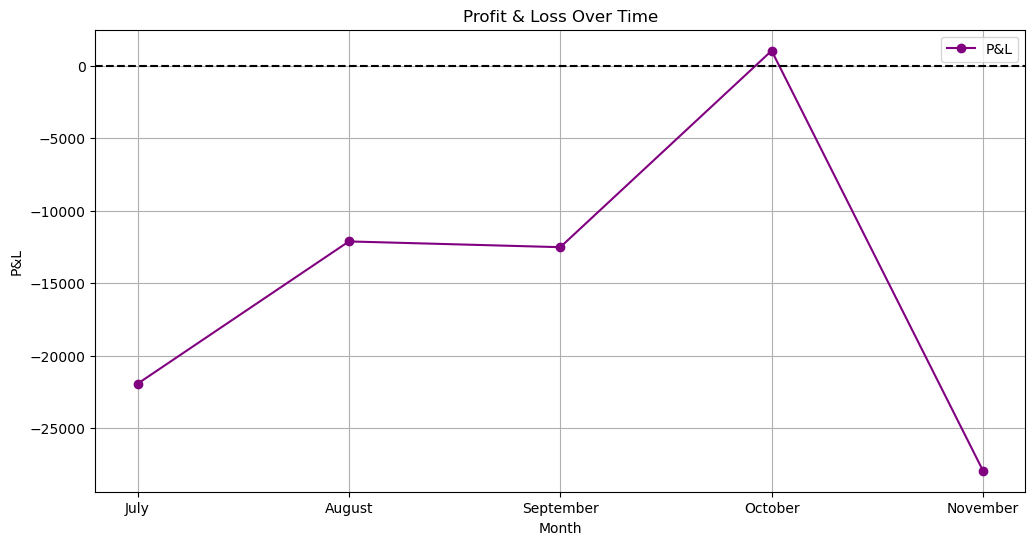

In [41]:
plt.figure(figsize=(12,6))
plt.plot(month_performance.index, month_performance['P&L'], marker='o', color='purple', label='P&L')

plt.title('Profit & Loss Over Time')
plt.xlabel('Month')
plt.ylabel('P&L')
plt.xticks(rotation=0)
plt.grid(True)
plt.axhline(0, color='black', linestyle='--')  # shows break-even line
plt.legend()
plt.show()

In [42]:
#October: The only month with a positive P&L, likely due to a high conversion rate following November.
#CTR was also strong, indicating the campaign successfully engaged the audience. 
#This suggests that the combination of ad targeting and promotions worked well this month

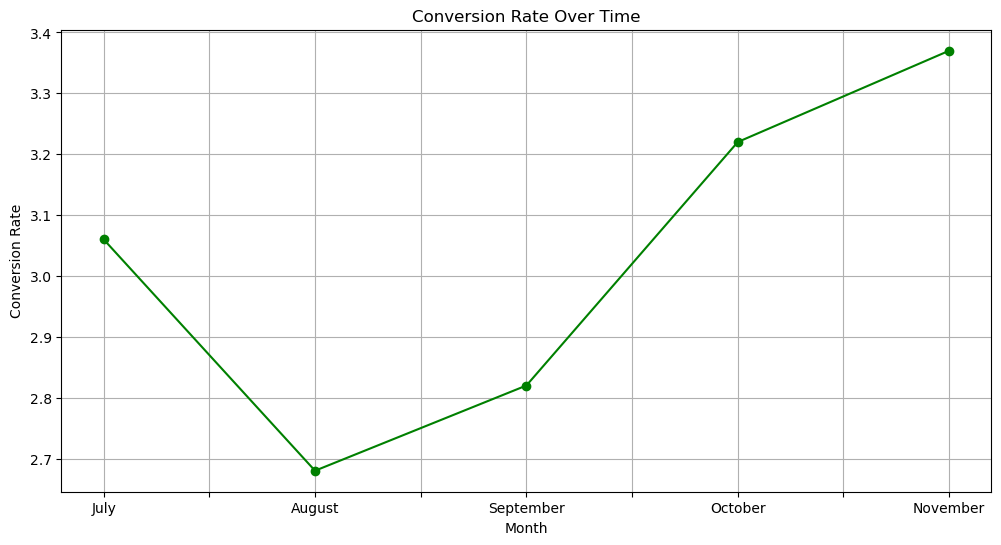

In [43]:
month_performance['Conv Rate'].plot(
    kind='line',
    marker='o',
    figsize=(12,6),
    color='green'
)

plt.title('Conversion Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [44]:
#•	August: Had the lowest conversion rate, indicating that while the campaign captured audience attention (clicks),
#it failed to convert them into sales. This suggests the offer may not have been attractive enough or 
#the keywords did not match users’ purchase intent.

In [45]:
month_clicks_impressions = df.groupby('Month')[['Impressions','Clicks']].sum()


C:\Users\hp\AppData\Local\Temp\ipykernel_17828\4017284733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_clicks_impressions = df.groupby('Month')[['Impressions','Clicks']].sum()


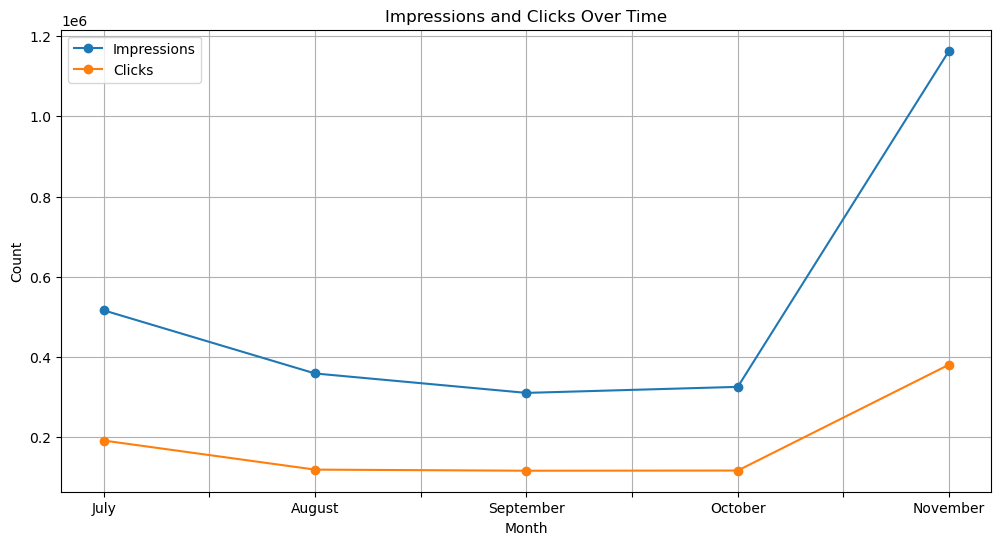

In [46]:
month_clicks_impressions.plot(kind='line', marker='o', figsize=(12,6))

plt.title('Impressions and Clicks Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

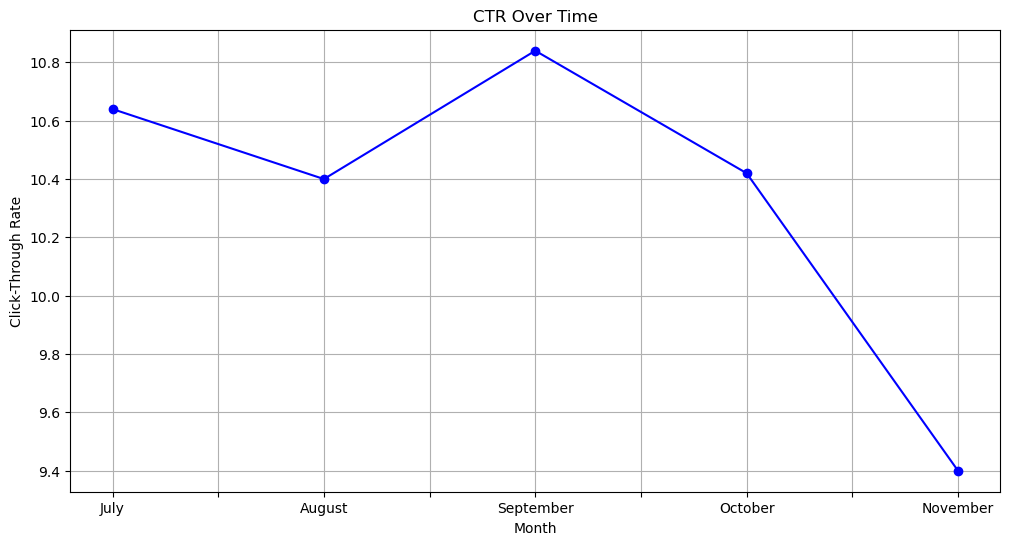

In [47]:
month_performance['CTR'].plot(
    kind='line',
    marker='o',
    figsize=(12,6),
    color='blue'
)

plt.title('CTR Over Time')
plt.xlabel('Month')
plt.ylabel('Click-Through Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [48]:
month_match_promo = df.groupby(['Month','Match_Type','Promotion_Type']).size().reset_index(name='Count')
month_match_promo

C:\Users\hp\AppData\Local\Temp\ipykernel_17828\1275424917.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_match_promo = df.groupby(['Month','Match_Type','Promotion_Type']).size().reset_index(name='Count')


,Month,Match_Type,Promotion_Type,Count
0,July,1:1,Black Friday/Cyber Monday,0
1,July,1:1,Competitor,0
2,July,1:1,Coupon Code,0
3,July,1:1,Discount Code,0
4,July,1:1,Free Shipping,0
...,...,...,...,...
190,November,Phrase,[shop coupon code],0
191,November,Phrase,[shop coupon],0
192,November,Phrase,[shop discount code],0
193,November,Phrase,[shop promo code],0


In [49]:
# Count campaigns by Month, Match Type, and Promotion Type
month_match_promo = df.groupby(
    ['Month', 'Match_Type', 'Promotion_Type']
).size().reset_index(name='Count')

C:\Users\hp\AppData\Local\Temp\ipykernel_17828\573690972.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_match_promo = df.groupby(


In [50]:
# Pivot the table so Promotion Types become columns
pivot_data = month_match_promo.pivot_table(
    index='Month',
    columns=['Match_Type', 'Promotion_Type'],
    values='Count',
    fill_value=0
)

C:\Users\hp\AppData\Local\Temp\ipykernel_17828\428998446.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = month_match_promo.pivot_table(


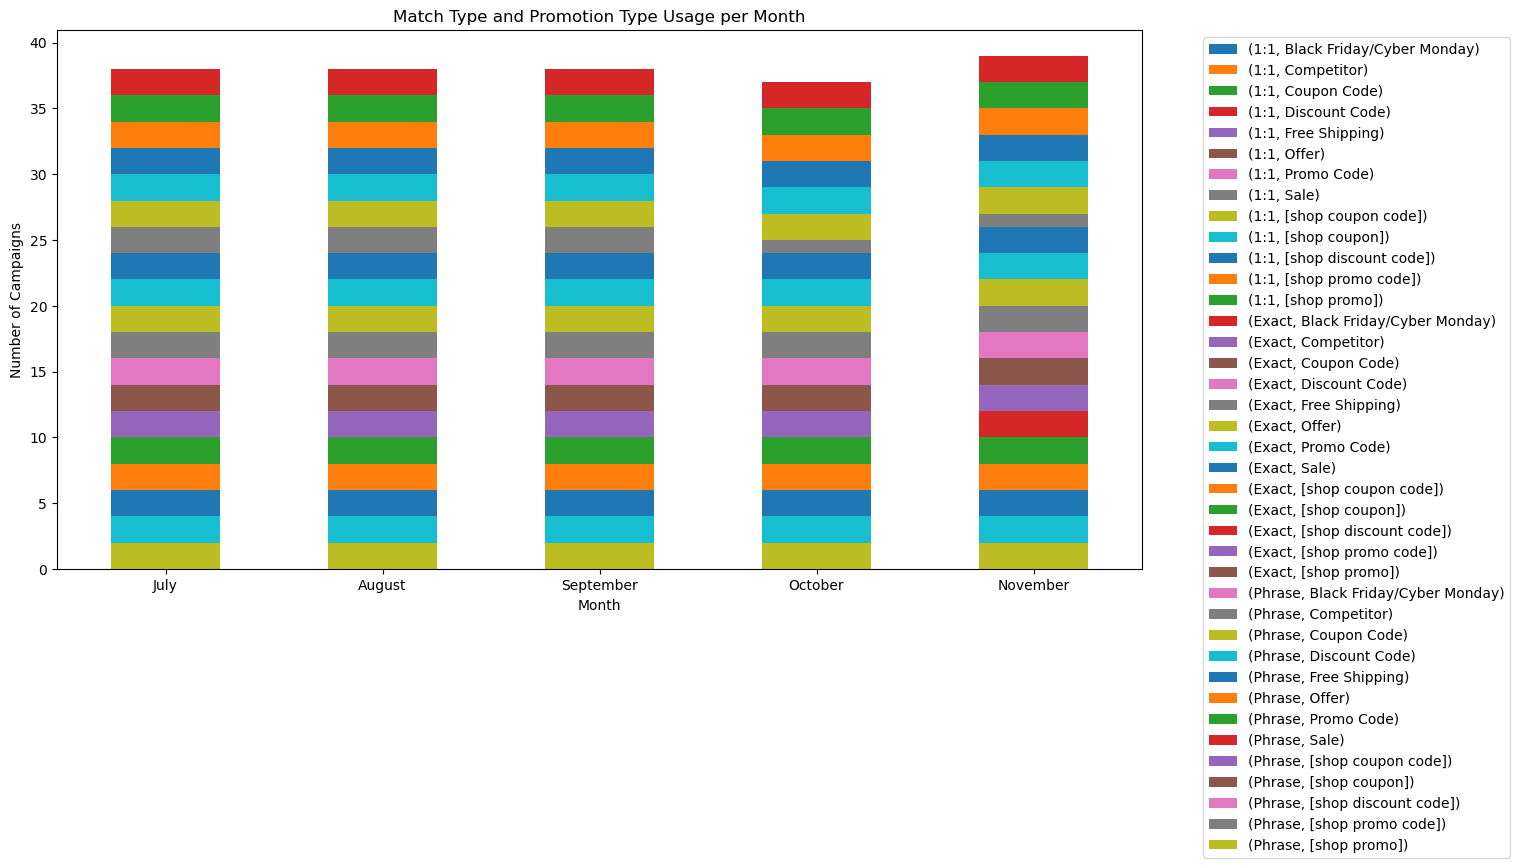

In [51]:
pivot_data.plot(kind='bar', stacked=True, figsize=(14,7))

plt.title('Match Type and Promotion Type Usage per Month')
plt.xlabel('Month')
plt.ylabel('Number of Campaigns')
plt.xticks(rotation=0)

# Move legend outside for clarity
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [52]:
#•	Overall Distribution: Match Type and Promotion Type appear to be evenly distributed across months,
#meaning their impact cannot be clearly isolated month by month. Each month’s performance seems largely influenced by user behavior
#and campaign timing rather than the types of promotions used



In [53]:
device_sales = df.groupby(['Month','Device'])['Sale Amount'].sum().unstack()
device_sales

C:\Users\hp\AppData\Local\Temp\ipykernel_17828\1196019446.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  device_sales = df.groupby(['Month','Device'])['Sale Amount'].sum().unstack()


Device,Desk,Mob
Month,,
July,1035468.92,1113241.40
August,811894.60,793171.40
September,628735.51,691213.63
October,711035.44,965558.06
November,2388301.96,2910453.39


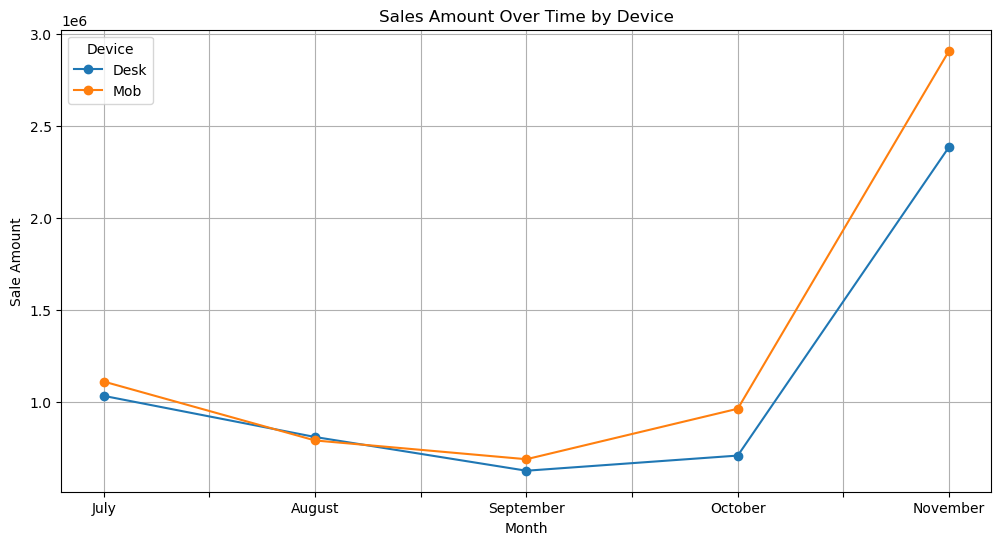

In [54]:
device_sales.plot(kind='line', marker='o', figsize=(12,6))

plt.title('Sales Amount Over Time by Device')
plt.xlabel('Month')
plt.ylabel('Sale Amount')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Device')
plt.show()

In [55]:
#regression analysis

In [56]:
model = smf.ols('Q("P&L") ~ CPC + Q("Conv Rate") + CTR + C(Promotion_Type) + C(Match_Type) + C(Device)', data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Q("P&L")   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     7.293
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.92e-13
Time:                        00:23:47   Log-Likelihood:                -1510.6
No. Observations:                 190   AIC:                             3057.
Df Residuals:                     172   BIC:                             3116.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [57]:
#	shop coupon → strong negative impact (~-1,844)
#	[shop promo] → positive impact (~+667)
#	Device = Mobile → slight negative impact (~-430 P&L)
#	Match Type (Exact/Phrase) → slight positive contribution


In [58]:
#final summary

In [59]:
#Top 5 campaigns by Revenue
top_revenue = df[['Ad Group','Revenue','P&L','Conversions','Sale Amount']].sort_values(by='Revenue', ascending=False).head(5)
print("Top 5 Campaigns by Revenue")
top_revenue

Top 5 Campaigns by Revenue


,Ad Group,Revenue,P&L,Conversions,Sale Amount
159,Shop - 1:1 - Mob - [shop promo code],42440,-1101.899,7563,886095.31
153,Shop - 1:1 - Desk - [shop promo code],34518,-3211.121,5782,725773.92
151,Shop - 1:1 - Mob - [shop coupon],32668,-5605.297,5961,677188.10
175,Shop - 1:1 - Mob - [shop coupon code],24071,-77.730,4349,500400.85
152,Shop - 1:1 - Desk - [shop coupon],23857,-3478.644,4080,497790.81


In [60]:
#Top 5 campaigns by Profit (P&L)
top_profit = df[['Ad Group','Revenue','P&L','Conversions','Sale Amount']].sort_values(by='P&L', ascending=False).head(5)
print("Top 5 Campaigns by Profit (P&L)")
top_profit

Top 5 Campaigns by Profit (P&L)


,Ad Group,Revenue,P&L,Conversions,Sale Amount
114,Shop - 1:1 - Mob - [shop coupon],13744,1507.685,2444,285638.30
115,Shop - 1:1 - Mob - [shop promo code],12025,766.859,2193,252296.27
118,Shop - 1:1 - Mob - [shop coupon code],7955,762.921,1393,166656.05
125,Shop - 1:1 - Mob - [shop discount code],1889,342.979,269,40122.76
123,Shop - Exact - Mob - Coupon Code,2655,337.125,440,55815.23


In [61]:
# Top 5 campaigns by Conversion Rate
top_conv_rate = df[['Ad Group','Conv Rate','CTR','Conversions','Revenue']].sort_values(by='Conv Rate', ascending=False).head(5)
print("Top 5 Campaigns by Conversion Rate")
top_conv_rate

Top 5 Campaigns by Conversion Rate


,Ad Group,Conv Rate,CTR,Conversions,Revenue
112,Shop - Phrase - Desk - Free Shipping,0.50,0.08,1,20
24,Shop - Phrase - Desk - Competitor,0.33,0.14,2,13
185,Shop - Exact - Desk - Black Friday/Cyber Monday,0.28,0.09,7,45
150,Shop - Phrase - Mob - Free Shipping,0.21,0.14,3,4
28,Shop - Phrase - Desk - Offer,0.19,0.14,10,63


In [62]:
# Bottom 5 campaigns by Profit (biggest losses)
worst_profit = df[['Ad Group','Revenue','P&L','Conversions','Sale Amount']].sort_values(by='P&L').head(5)
print("Bottom 5 Campaigns by Profit (Biggest Losses)")
worst_profit

Bottom 5 Campaigns by Profit (Biggest Losses)


,Ad Group,Revenue,P&L,Conversions,Sale Amount
6,Shop - 1:1 - Mob - [shop coupon],13699,-5672.271,2666,294536.92
151,Shop - 1:1 - Mob - [shop coupon],32668,-5605.297,5961,677188.10
5,Shop - 1:1 - Mob - [shop coupon code],8550,-4606.713,1665,185824.49
152,Shop - 1:1 - Desk - [shop coupon],23857,-3478.644,4080,497790.81
153,Shop - 1:1 - Desk - [shop promo code],34518,-3211.121,5782,725773.92


In [63]:
#Summary by Device
device_summary = df.groupby('Device')[['Revenue','Cost','P&L','Clicks','Conversions','Sale Amount']].sum().reset_index()
print("Summary by Device")
device_summary

Summary by Device


,Device,Revenue,Cost,P&L,Clicks,Conversions,Sale Amount
0,Desk,258831,286841,-28007.319,234939,42190,5575436.43
1,Mob,303129,348531,-45401.445,689564,53806,6473637.88


In [64]:
# Summary by Promotion Type
promo_summary = df.groupby('Promotion_Type')[['Revenue','Cost','P&L','Clicks','Conversions','Sale Amount']].sum().reset_index()
promo_summary = promo_summary.sort_values(by='P&L', ascending=False)
print("Summary by Promotion Type")
promo_summary

Summary by Promotion Type


,Promotion_Type,Revenue,Cost,P&L,Clicks,Conversions,Sale Amount
0,Black Friday/Cyber Monday,205,47,157.909,290,31,4167.43
4,Free Shipping,555,742,-184.863,2597,252,13591.56
12,[shop promo],4694,5108,-413.102,5978,802,100236.60
1,Competitor,1634,2114,-480.266,3479,270,34785.62
10,[shop discount code],19849,21331,-1481.620,26512,3079,430390.57
5,Offer,8934,12126,-3190.626,15236,1376,186751.70
3,Discount Code,10646,14136,-3491.757,22350,1549,237264.07
6,Promo Code,76270,80920,-4649.720,92585,12159,1661141.84
7,Sale,4267,10645,-6377.476,17313,695,89993.81
2,Coupon Code,45545,51987,-6442.721,81479,7276,1000710.55


In [65]:
# Summary by Match Type
match_summary = df.groupby('Match_Type')[['Revenue','Cost','P&L','Clicks','Conversions','Sale Amount']].sum().reset_index()
match_summary = match_summary.sort_values(by='P&L', ascending=False)
print("Summary by Match Type")
match_summary

Summary by Match Type


,Match_Type,Revenue,Cost,P&L,Clicks,Conversions,Sale Amount
1,Exact,93298,105319,-12019.428,149042,15038,2044743.76
2,Phrase,54758,67398,-12640.092,86287,8570,1183662.82
0,1:1,413904,462655,-48749.244,689174,72388,8820667.73
